In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("../dataset/processed/cardio_cleaned.csv")

# Separate features (X) and target (y)
# We drop 'age' (days) since we have 'age_years', and drop target 'cardio'
feature_cols = ["age_years", "gender", "height", "weight", "ap_hi", "ap_lo", 
                "cholesterol", "gluc", "smoke", "alco", "active", "bmi"]

X = df[feature_cols].values
y = df["cardio"].values

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (68554, 12)
y shape: (68554,)


In [3]:
# 1. Train / Test Split (80% Train, 20% Test)
np.random.seed(42)
indices = np.random.permutation(len(X))
split_idx = int(0.8 * len(X))

train_indices = indices[:split_idx]
test_indices = indices[split_idx:]

X_train, X_test = X[train_indices], X[test_indices]
y_train, y_test = y[train_indices], y[test_indices]

# 2. Standardization (Z-score scaling: (X - mean) / std)
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)

# Replace 0 std with 1 to avoid division by zero
std[std == 0] = 1.0

X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std  # Use training mean & std!

print(f"Training samples: {X_train_scaled.shape[0]}, Testing samples: {X_test_scaled.shape[0]}")

Training samples: 54843, Testing samples: 13711


In [4]:
class ScratchLogisticRegression:
    def __init__(self, learning_rate=0.1, n_iterations=1000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.weights = None
        self.bias = None
        self.loss_history = []

    def _sigmoid(self, z):
        # Clip z to prevent numerical overflow in exp(-z)
        z = np.clip(z, -500, 500)
        return 1.0 / (1.0 + np.exp(-z))

    def _compute_loss(self, y_true, y_pred_prob):
        m = len(y_true)
        # Clip probabilities to avoid log(0)
        epsilon = 1e-15
        y_pred_prob = np.clip(y_pred_prob, epsilon, 1 - epsilon)
        
        loss = - (1 / m) * np.sum(
            y_true * np.log(y_pred_prob) + (1 - y_true) * np.log(1 - y_pred_prob)
        )
        return loss

    def fit(self, X, y):
        m, n = X.shape
        
        # Initialize weights with zeros
        self.weights = np.zeros(n)
        self.bias = 0.0
        self.loss_history = []

        # Gradient Descent Loop
        for i in range(self.n_iterations):
            # 1. Forward Pass: Linear combination + Sigmoid
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred_prob = self._sigmoid(linear_model)

            # 2. Compute and store loss
            loss = self._compute_loss(y, y_pred_prob)
            self.loss_history.append(loss)

            # 3. Backward Pass: Compute Gradients
            dw = (1 / m) * np.dot(X.T, (y_pred_prob - y))
            db = (1 / m) * np.sum(y_pred_prob - y)

            # 4. Parameter Update
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

            # Print progress every 100 iterations
            if (i + 1) % 100 == 0 or i == 0:
                print(f"Iteration {i+1}/{self.n_iterations} - Loss: {loss:.5f}")

    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return self._sigmoid(linear_model)

    def predict(self, X, threshold=0.5):
        probabilities = self.predict_proba(X)
        return (probabilities >= threshold).astype(int)

In [5]:
# Instantiate and fit the model
model_scratch = ScratchLogisticRegression(learning_rate=0.1, n_iterations=1000)
model_scratch.fit(X_train_scaled, y_train)

Iteration 1/1000 - Loss: 0.69315
Iteration 100/1000 - Loss: 0.56513
Iteration 200/1000 - Loss: 0.56258
Iteration 300/1000 - Loss: 0.56182
Iteration 400/1000 - Loss: 0.56151
Iteration 500/1000 - Loss: 0.56138
Iteration 600/1000 - Loss: 0.56133
Iteration 700/1000 - Loss: 0.56130
Iteration 800/1000 - Loss: 0.56129
Iteration 900/1000 - Loss: 0.56129
Iteration 1000/1000 - Loss: 0.56129


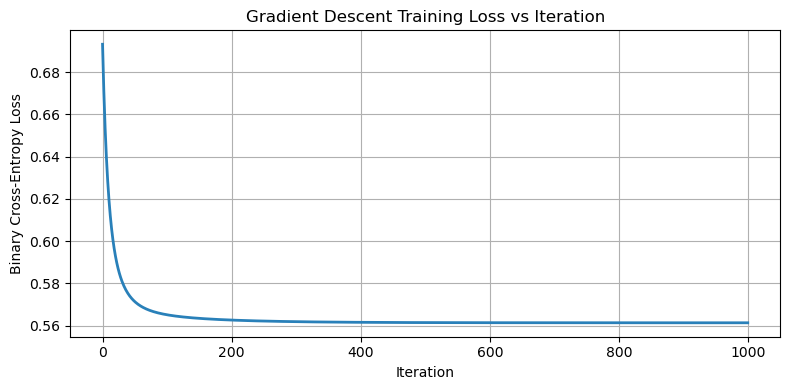

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(model_scratch.loss_history, color="#2980b9", lw=2)
plt.title("Gradient Descent Training Loss vs Iteration")
plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.grid(True)
plt.tight_layout()
plt.show()

In [7]:
# Make predictions on test set
y_pred = model_scratch.predict(X_test_scaled)
y_pred_prob = model_scratch.predict_proba(X_test_scaled)

# 1. Confusion Matrix
TP = np.sum((y_test == 1) & (y_pred == 1))
TN = np.sum((y_test == 0) & (y_pred == 0))
FP = np.sum((y_test == 0) & (y_pred == 1))
FN = np.sum((y_test == 1) & (y_pred == 0))

# 2. Metrics Calculation
accuracy = (TP + TN) / len(y_test)
precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"--- Scratch Model Evaluation ---")
print(f"Accuracy  : {accuracy * 100:.2f}%")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1_score:.4f}")
print(f"\nConfusion Matrix:")
print(f"  [TN: {TN} | FP: {FP}]")
print(f"  [FN: {FN} | TP: {TP}]")

--- Scratch Model Evaluation ---
Accuracy  : 73.17%
Precision : 0.7559
Recall    : 0.6759
F1 Score  : 0.7137

Confusion Matrix:
  [TN: 5449 | FP: 1480]
  [FN: 2198 | TP: 4584]


In [8]:
# Inspect which features have highest positive/negative weights
weights_df = pd.DataFrame({
    "Feature": feature_cols,
    "Weight (w)": model_scratch.weights
}).sort_values(by="Weight (w)", ascending=False)

print(weights_df)

        Feature  Weight (w)
4         ap_hi    0.918268
0     age_years    0.342479
6   cholesterol    0.332484
5         ap_lo    0.112158
3        weight    0.090727
11          bmi    0.071234
2        height    0.006558
1        gender   -0.007030
8         smoke   -0.041005
9          alco   -0.051684
7          gluc   -0.063084
10       active   -0.094615


In [9]:

print("=== 1. Training WITHOUT Scaling ===")
model_unscaled = ScratchLogisticRegression(learning_rate=0.0001, n_iterations=1000)
model_unscaled.fit(X_train, y_train)

y_pred_unscaled = model_unscaled.predict(X_test)
acc_unscaled = np.mean(y_pred_unscaled == y_test) * 100
print(f"Accuracy WITHOUT Scaling: {acc_unscaled:.2f}%\n")

=== 1. Training WITHOUT Scaling ===
Iteration 1/1000 - Loss: 0.69315
Iteration 100/1000 - Loss: 0.63751
Iteration 200/1000 - Loss: 0.61458
Iteration 300/1000 - Loss: 0.60387
Iteration 400/1000 - Loss: 0.59825
Iteration 500/1000 - Loss: 0.59500
Iteration 600/1000 - Loss: 0.59295
Iteration 700/1000 - Loss: 0.59155
Iteration 800/1000 - Loss: 0.59052
Iteration 900/1000 - Loss: 0.58971
Iteration 1000/1000 - Loss: 0.58904
Accuracy WITHOUT Scaling: 70.66%



In [10]:
print("=== 2. Training WITH Scaling ===")
model_scaled = ScratchLogisticRegression(learning_rate=0.1, n_iterations=1000)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)
acc_scaled = np.mean(y_pred_scaled == y_test) * 100
print(f"Accuracy WITH Scaling: {acc_scaled:.2f}%\n")


=== 2. Training WITH Scaling ===
Iteration 1/1000 - Loss: 0.69315
Iteration 100/1000 - Loss: 0.56513
Iteration 200/1000 - Loss: 0.56258
Iteration 300/1000 - Loss: 0.56182
Iteration 400/1000 - Loss: 0.56151
Iteration 500/1000 - Loss: 0.56138
Iteration 600/1000 - Loss: 0.56133
Iteration 700/1000 - Loss: 0.56130
Iteration 800/1000 - Loss: 0.56129
Iteration 900/1000 - Loss: 0.56129
Iteration 1000/1000 - Loss: 0.56129
Accuracy WITH Scaling: 73.17%



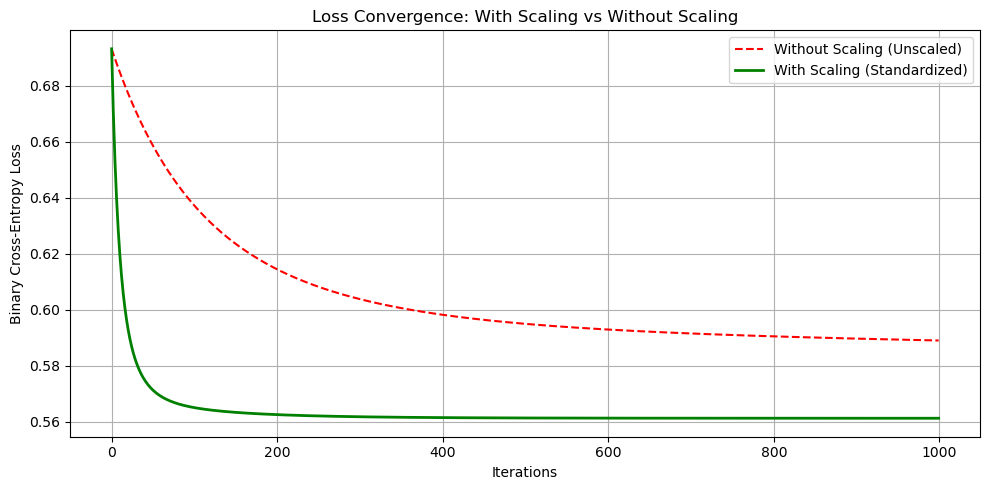

In [12]:
plt.figure(figsize=(10, 5))
plt.plot(model_unscaled.loss_history, label="Without Scaling (Unscaled)", color="red", linestyle="--")
plt.plot(model_scaled.loss_history, label="With Scaling (Standardized)", color="green", lw=2)

plt.title("Loss Convergence: With Scaling vs Without Scaling")
plt.xlabel("Iterations")
plt.ylabel("Binary Cross-Entropy Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()